In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyarrow
import seaborn as sns


In [84]:
df = pd.read_parquet("cleaned_data.parquet", engine="pyarrow")


---

# Check Errors

In [85]:
df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State,...,Profit,Shipping Days,Order Weekday,Order Month,Order Quarter,Order Year,Is Weekend,Unit Price,Profit Margin,Discount_Level
0,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,41.9136,3,Thursday,11,4,2018,False,130.9800,16.00,No Discount
1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,...,219.5820,3,Thursday,11,4,2018,False,243.9800,30.00,No Discount
2,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,...,6.8714,4,Tuesday,6,2,2018,False,7.3100,47.00,No Discount
3,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,-383.0310,7,Wednesday,10,4,2017,False,191.5155,-40.00,Medium Discount
4,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,...,2.5164,7,Wednesday,10,4,2017,False,11.1840,11.25,Low Discount


In [86]:
df.isnull().sum()

Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State             0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
Shipping Days     0
Order Weekday     0
Order Month       0
Order Quarter     0
Order Year        0
Is Weekend        0
Unit Price        0
Profit Margin     0
Discount_Level    0
dtype: int64

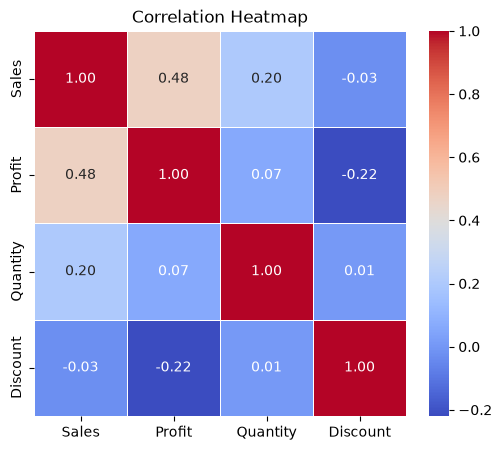

In [87]:
corr = df[["Sales", "Profit", "Quantity", "Discount"]].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

---

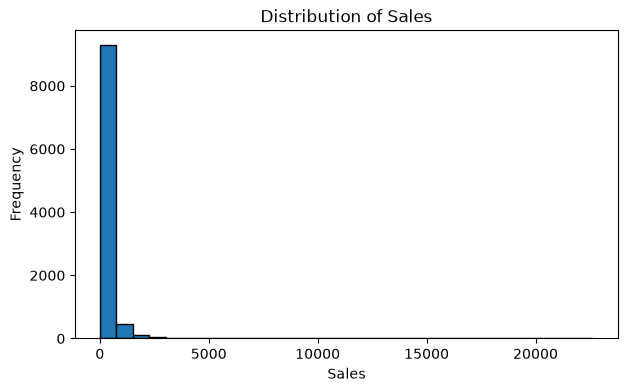

In [88]:
plt.figure(figsize=(7,4))
plt.hist(df["Sales"], bins=30, edgecolor="black")
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

count     9993.000000
mean       229.852846
std        623.276074
min          0.444000
25%         17.280000
50%         54.480000
75%        209.940000
max      22638.480000
Name: Sales, dtype: float64
Skewness : 12.97


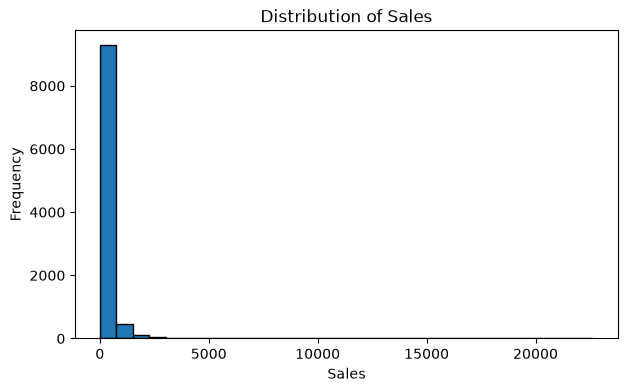

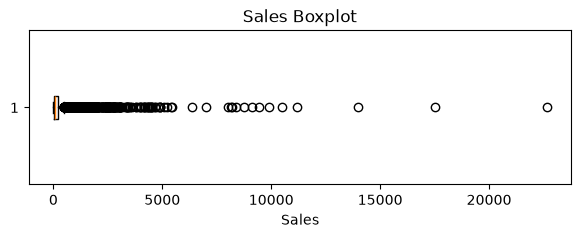

In [89]:
print(df["Sales"].describe())

print(f"Skewness : {df['Sales'].skew():.2f}")
plt.figure(figsize=(7,4))
plt.hist(df["Sales"], bins=30, edgecolor="black")
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(7,2))
plt.boxplot(df["Sales"], orientation="horizontal")
plt.title("Sales Boxplot")
plt.xlabel("Sales")
plt.show()

count    9993.000000
mean       28.660971
std       234.271476
min     -6599.978000
25%         1.731000
50%         8.671000
75%        29.364000
max      8399.976000
Name: Profit, dtype: float64
Skewness : 7.56


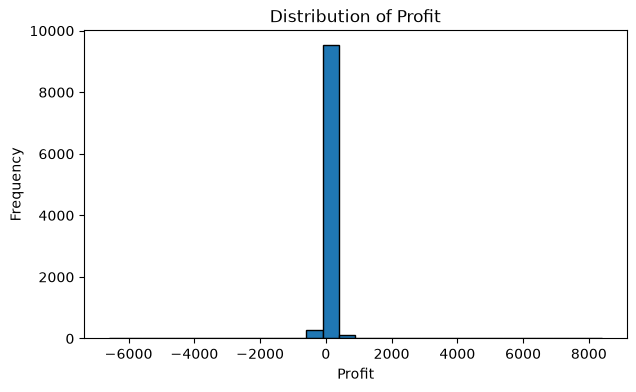

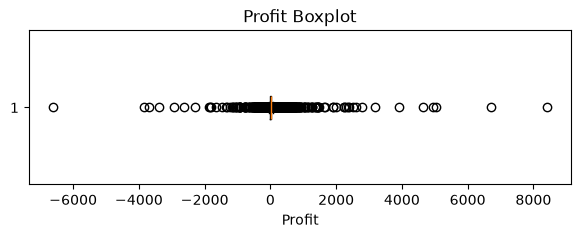

In [90]:
print(df["Profit"].describe())

print(f"Skewness : {df['Profit'].skew():.2f}")

plt.figure(figsize=(7,4))
plt.hist(df["Profit"], bins=30, edgecolor="black")
plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(7,2))
plt.boxplot(df["Profit"], orientation="horizontal")
plt.title("Profit Boxplot")
plt.xlabel("Profit")
plt.show()

count    9993.000000
mean        0.156188
std         0.206457
min         0.000000
25%         0.000000
50%         0.200000
75%         0.200000
max         0.800000
Name: Discount, dtype: float64
Skewness : 1.68
Kurtosis : 2.41


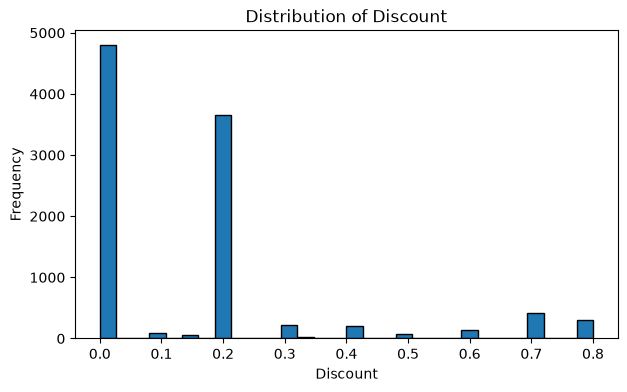

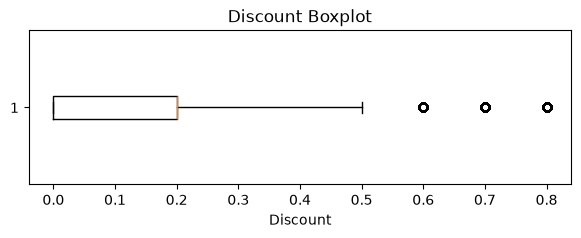

In [91]:
print(df["Discount"].describe())

print(f"Skewness : {df['Discount'].skew():.2f}")
print(f"Kurtosis : {df['Discount'].kurt():.2f}")

plt.figure(figsize=(7,4))
plt.hist(df["Discount"], bins=30, edgecolor="black")
plt.title("Distribution of Discount")
plt.xlabel("Discount")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(7,2))
plt.boxplot(df["Discount"], orientation="horizontal")
plt.title("Discount Boxplot")
plt.xlabel("Discount")
plt.show()

### The Discount variable is a discrete numerical feature with values concentrated at a limited number of predefined discount levels rather than being continuously distributed. Most orders received no discount (0%), while a 20% discount is the second most frequent value. Higher discount rates (50%–80%) occur relatively infrequently, indicating that substantial discounts are applied only to a small proportion of orders. Overall, the distribution is highly non-normal and characterized by distinct peaks at specific discount levels

## Category Analysis

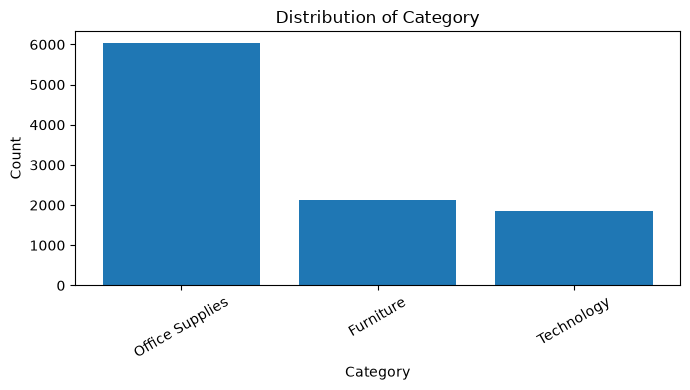

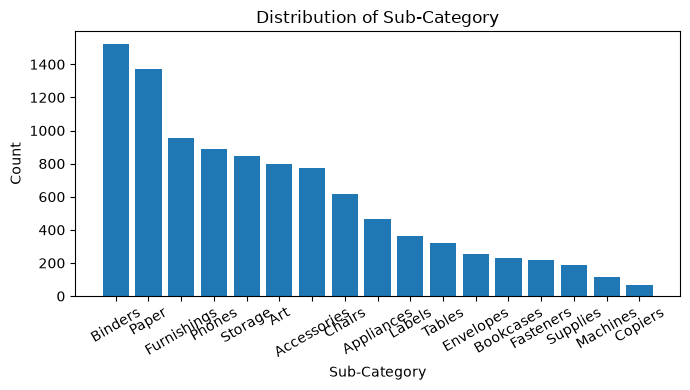

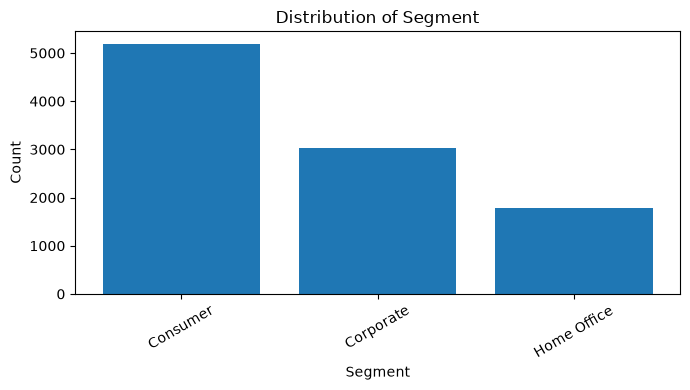

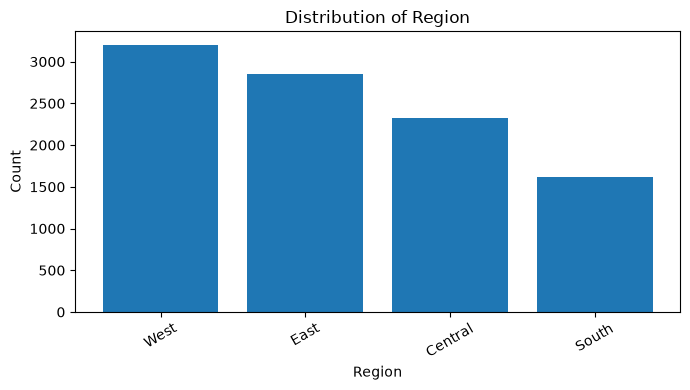

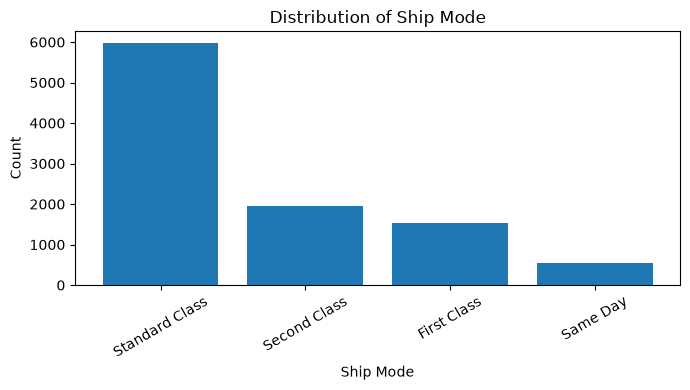

In [92]:
cat_cols = ["Category", "Sub-Category", "Segment", "Region", "Ship Mode"]

for col in cat_cols:
    counts = df[col].value_counts()

    plt.figure(figsize=(7,4))
    plt.bar(counts.index, counts.values)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

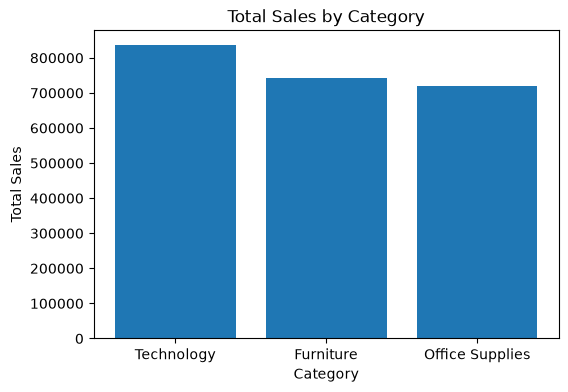

In [93]:
sales_by_category = df.groupby("Category", observed=True)["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(6,4))
plt.bar(sales_by_category.index, sales_by_category.values)
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

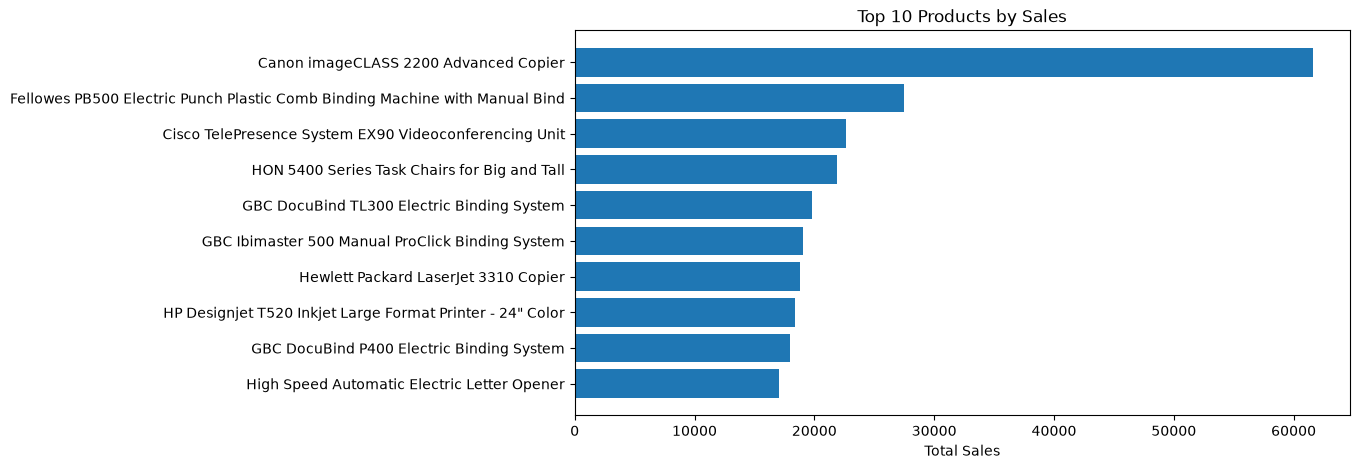

In [94]:
top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .nlargest(10)
)

plt.figure(figsize=(10,5))
plt.barh(top_products.index, top_products.values)
plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.gca().invert_yaxis()
plt.show()

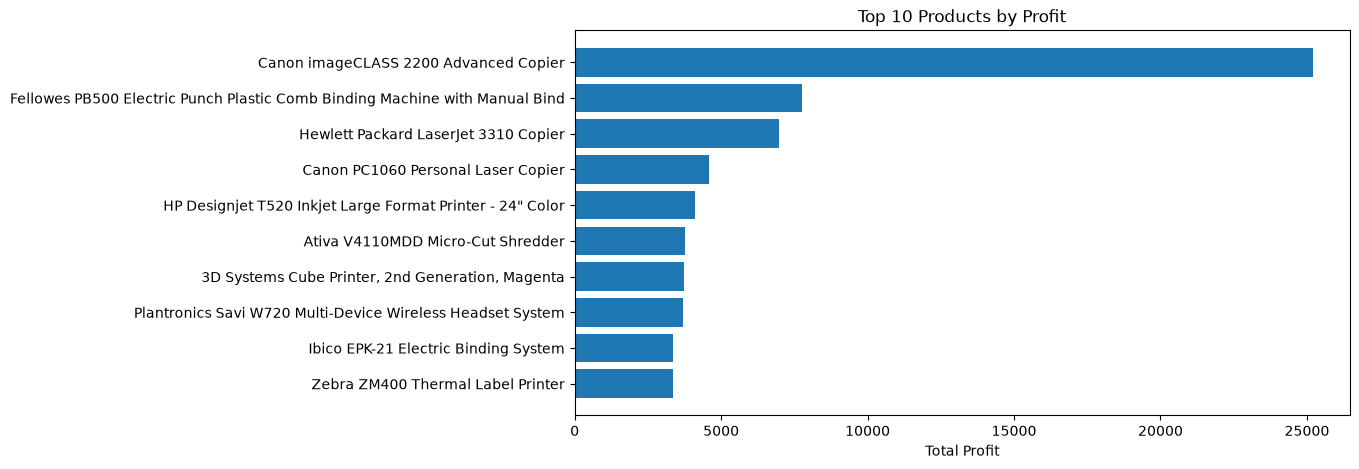

In [95]:
top_products = (
    df.groupby("Product Name")["Profit"]
      .sum()
      .nlargest(10)
)

plt.figure(figsize=(10,5))
plt.barh(top_products.index, top_products.values)
plt.title("Top 10 Products by Profit")
plt.xlabel("Total Profit")
plt.gca().invert_yaxis()
plt.show()

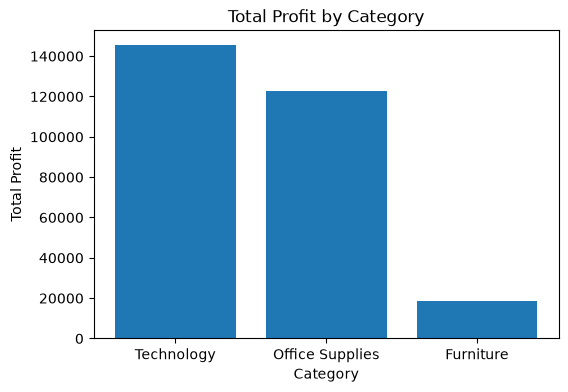

In [96]:
profit_by_category = (
    df.groupby("Category", observed=True)["Profit"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(6,4))
plt.bar(profit_by_category.index, profit_by_category.values)
plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.show()

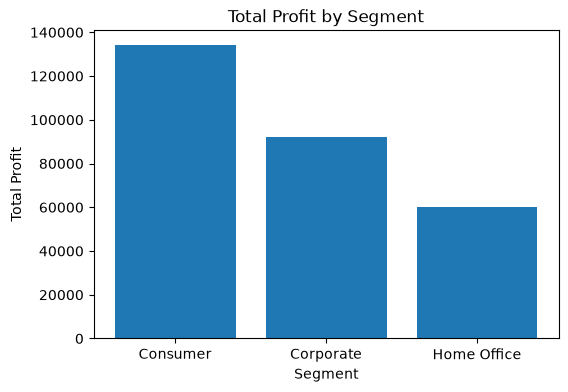

In [97]:
profit_by_segment = (
    df.groupby("Segment", observed=True)["Profit"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(6,4))
plt.bar(profit_by_segment.index, profit_by_segment.values)
plt.title("Total Profit by Segment")
plt.xlabel("Segment")
plt.ylabel("Total Profit")
plt.show()

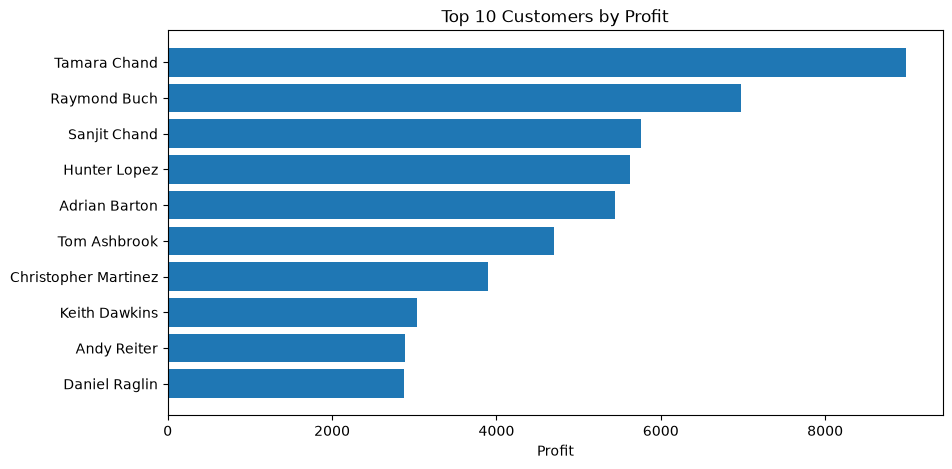

In [98]:
top_customers_profit = (
    df.groupby("Customer Name")["Profit"]
      .sum()
      .nlargest(10)
)

plt.figure(figsize=(10,5))
plt.barh(top_customers_profit.index, top_customers_profit.values)
plt.title("Top 10 Customers by Profit")
plt.xlabel("Profit")
plt.gca().invert_yaxis()
plt.show()

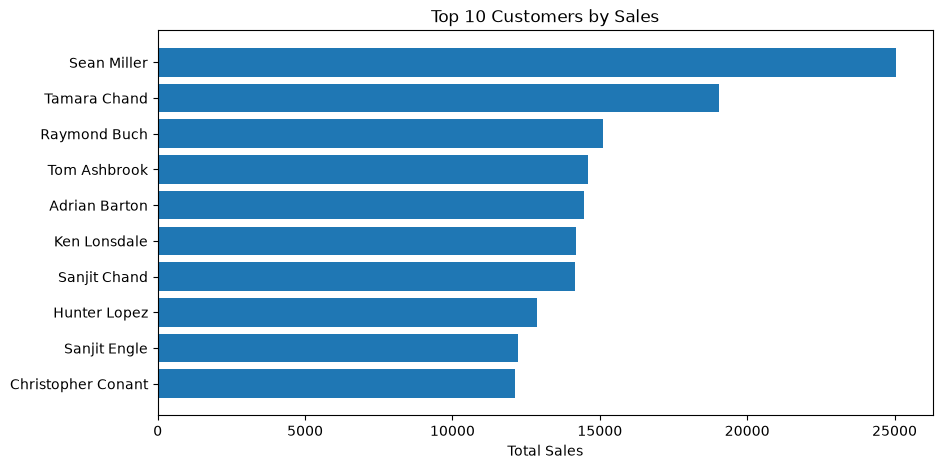

In [99]:
top_customers = (
    df.groupby("Customer Name")["Sales"]
      .sum()
      .nlargest(10)
)

plt.figure(figsize=(10,5))
plt.barh(top_customers.index, top_customers.values)
plt.title("Top 10 Customers by Sales")
plt.xlabel("Total Sales")
plt.gca().invert_yaxis()
plt.show()

---

# Sales @ Profit By Month

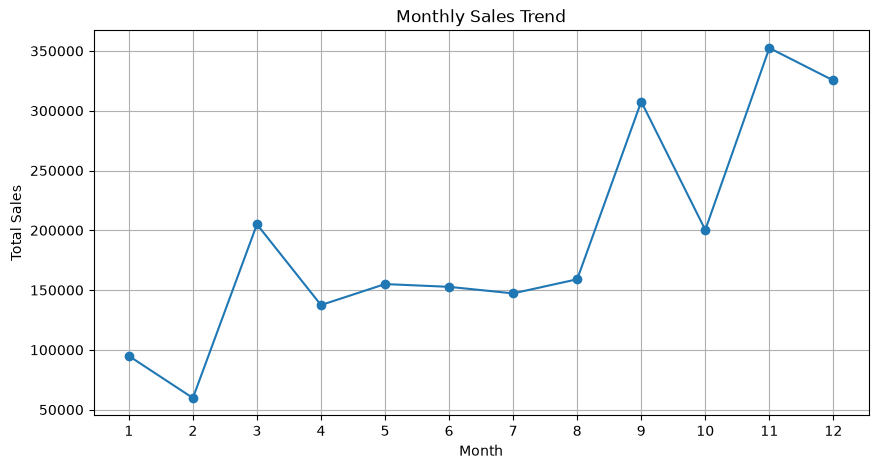

In [100]:
monthly_sales = (
    df.groupby("Order Month", observed=True)["Sales"]
      .sum()
)

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(range(1,13))
plt.grid(True)
plt.show()

### Monthly Sales Insight

- **November had the highest total sales of the year.**

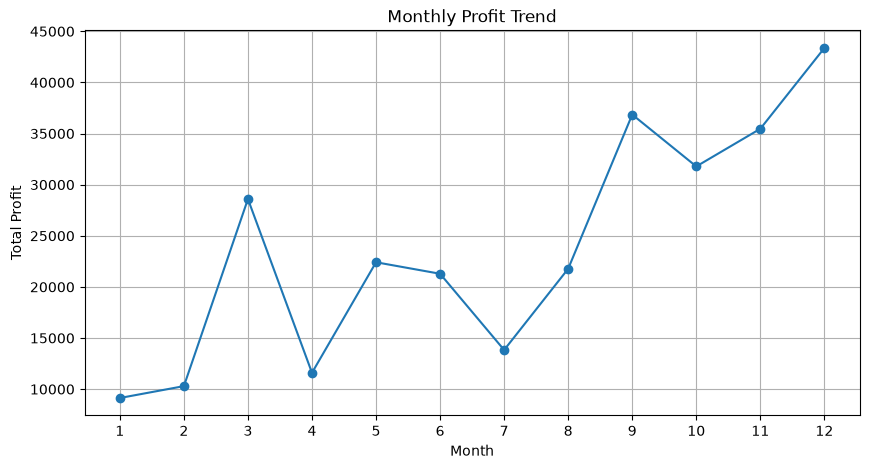

In [101]:
monthly_profit = (
    df.groupby("Order Month", observed=True)["Profit"]
      .sum()
)

plt.figure(figsize=(10,5))
plt.plot(monthly_profit.index, monthly_profit.values, marker="o")
plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Total Profit")
plt.xticks(range(1,13))
plt.grid(True)
plt.show()

###  Monthly Sales Insight

- **December recorded the highest total sales among all months*

---

# Sales @ Profit By Years

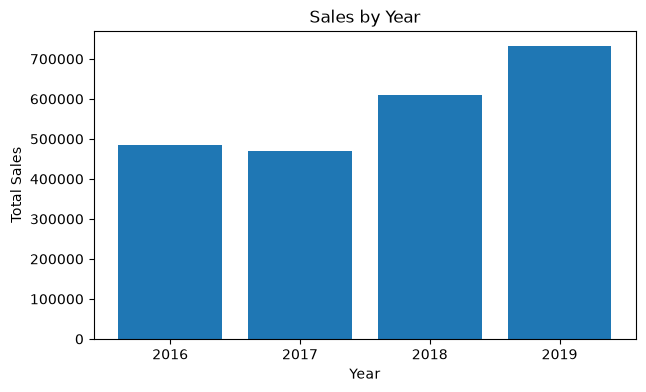

In [102]:
sales_by_year = (
    df.groupby("Order Year", observed=True)["Sales"]
      .sum()
)

plt.figure(figsize=(7,4))
plt.bar(sales_by_year.index.astype(str), sales_by_year.values)
plt.title("Sales by Year")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.show()

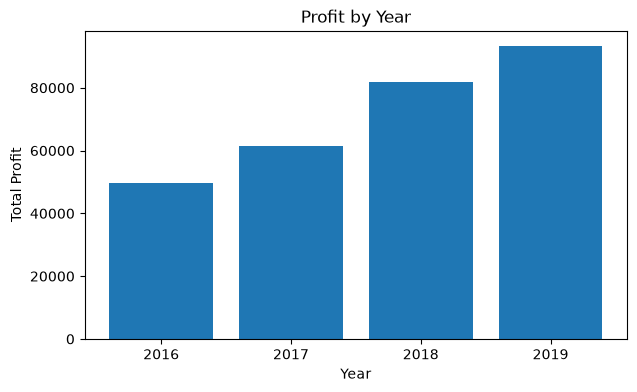

In [103]:
profit_by_year = (
    df.groupby("Order Year", observed=True)["Profit"]
      .sum()
)

plt.figure(figsize=(7,4))
plt.bar(profit_by_year.index.astype(str), profit_by_year.values)
plt.title("Profit by Year")
plt.xlabel("Year")
plt.ylabel("Total Profit")
plt.show()

### Correlation Analysis

- **Sales and Profit show a moderate positive correlation**, indicating that higher sales often lead to higher profits.
- **Discount has a negative correlation with Profit**, suggesting that larger discounts tend to reduce profitability.
- **Quantity has a weak positive correlation with Sales**, meaning larger order quantities generally increase sales.